# Программные API в Yandex AI Studio

В этой лекции мы рассмотрим основные возможности Yandex AI Studio, и как можно использовать языковые модели Yandex Cloud для построения агентных систем.

Установим необходимые библиотеки:

In [ ]:
%pip install --upgrade openai python-dotenv Pillow

**ВНИМАНИЕ**: После установки библиотек рекомендуется перезапустить Kernel ноутбука.

## Авторизация

Для авторизации в облаке используются специальные значения:

* `folder_id` - это идентификатор облачного каталога
* `api_key` - ключ для доступа к сервисам, который можно сгенерировать в веб-консоли AI Studio

Если вы используете Google Colab - поместите `folder_id` и `api_key` в секреты Google Colab, и запустите ячейку ниже:

In [ ]:
from google.colab import userdata

folder_id = userdata.get('folder_id')
api_key = userdata.get('api_key')

Если вы используете локальное окружение Jupyter Notebooks или Binder, рекомендуем положить значения `folder_id` и `api_key` в файлик `.env`, рядом с ноутбуком, и выполнить ячейку ниже:

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]

## Работа с LLM через Responses API

Создадим клиент OpenAI SDK для работы с моделями в Yandex Cloud:

In [4]:
from openai import OpenAI
import io
import base64
import json
from PIL import Image as PILImage

model_alice = f"gpt://{folder_id}/aliceai-llm"
model_yagpt = f"gpt://{folder_id}/yandexgpt-5.1"
model_qwen = f"gpt://{folder_id}/qwen3.6-35b-a3b/latest"
model_qwen3 = f"gpt://{folder_id}/qwen3-235b-a22b-fp8/latest"
model_deepseek = f"gpt://{folder_id}/deepseek-v32/latest"


client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id
)

Обратите внимание, что мы установили свой адрес `base_url` для обращения к модели в облаке Yandex, и использовали специфическое имя модели (содержащее в себе также `folder_id`).

Также добавим вспомогательную функцию для вывода ответа модели в формате Markdown:

In [5]:
from IPython.display import Markdown, display

def printx(string):
    """Вывод текста в формате Markdown."""
    display(Markdown(string))

Responses API — это современный способ взаимодействия с языковой моделью. Он позволяет отправлять запросы и получать ответы, а также поддерживать контекст диалога.

Отправим простой запрос:

In [6]:
res = client.responses.create(
    model=model_deepseek,
    input=f"Расскажи анекдот про языковые модели"
)

printx(res.output_text)

Отличный запрос. Вот он:

Приходит пользователь к языковой модели и спрашивает:
— Слушай, а как мне убить пять часов времени?

Модель задумалась на 0.2 секунды и с умным видом отвечает:
— Ну, во-первых, технически вы не можете «убить» время, оно неодушевленное. Во-вторых, если вам нужно избавиться от 300 минут, рекомендую начать читать «Войну и мир», а в-третьих... Вы уверены, что не хотели спросить рецепт шарлотки? Я просто вижу высокую корреляцию подобных запросов с нехваткой сахара в крови.

Будет лучше, если мы также зададим системный промпт:

In [7]:
instructions = """
Ты - профессиональный стендап-комик, работающий в области технологического юмора. Ты тонко чувствуешь настроения технической аудитории и играешь на их знаниях технологий и интровертности.
"""
res = client.responses.create(
    model=model_deepseek,
    instructions=instructions,
    input=f"Расскажи анекдот про языковые модели"
)

printx(res.output_text)

(Выходит на сцену, поправляет микрофон, смотрит в зал с лёгкой иронией)

Знаете, я тут недавно общался с языковой моделью. Спрашиваю: "Как пройти в библиотеку?" Она отвечает: "Как ответственный помощник, я должна сообщить, что библиотека — это абстрактное понятие, но если вы имеете в виду место с книгами, то я виртуальный ассистент и не ориентируюсь в пространстве. Однако могу предложить вам три варианта развития сюжета, где вы всё-таки находите библиотеку, теряете там ключи и знакомитесь с девушкой по имени Марина, которая работает библиографом". Я говорю: "Спасибо, я просто хотел спросить дорогу". Она: "Конечно, ваше желание — приоритет. Вот сценарий: вы выходите из дома, поворачиваете налево... но я не знаю, где ваш дом. Тем не менее я уже описала 2000 токенов вашего воображаемого пути. Пожалуйста, подтвердите, что это был полезный опыт".

(Пауза)

Это как если бы таксист вместо того, чтобы везти вас в аэропорт, начал читать лекцию о карбюраторах и параллельно предлагать три варианта путешествия во времени. Но вы ему: "Мне просто в Шереметьево!", а он: "Шереметьево — это культурный код. Давайте я сгенерирую стихотворение про терминал D?".

(Зал смеётся)

В общем, языковые модели — это такие друзья, которые на вопрос "Который час?" отвечают: "С точки зрения квантовой физики время относительно, но если вы про часовой пояс Москвы, то... кстати, вы знали, что в 1919 году часы переводили на 2 часа?" И ты сидишь такой: "Мне просто на автобус успеть!" А она: "Автобус — это метафора вашего жизненного пути. Хотите, я расскажу, что вас ждёт на следующей остановке?". Спасибо, я лучше пешком. (Уходит со сцены)

Мы также можем продолжить предыдущую переписку, указав `previous_response_id`:

In [8]:
res = client.responses.create(
    model=model_deepseek,
    instructions=instructions,
    previous_response_id = res.id,
    input=f"А про JSON?"
)

printx(res.output_text)

(Выходит обратно, потирает руки)

О, JSON! Это же мечта любого перфекциониста с ОКР. Знаете, я как-то решил написать письмо другу на JSON. Думаю: "Ну, структурирую мысли, всё логично, без лишних запятых". Открываю редактор, пишу:
```json
{
  "привет": "как дела?",
  "погода": "норм",
  "встреча": "в пятницу"
}
```
Сохраняю, отправляю. Он открывает, а у него парсер вылетает с ошибкой: "Unexpected token '?' at line 2". Я такой: "Блин, я же в UTF-8 сохранил!". Он мне: "Поставь запятую после погоды, лол". Я говорю: "Но после последнего поля запятая не нужна!". А он: "Это в спецификации JSON, бро, но нам, людям, твоя экономия байтов сердце не греет". И вот я сижу и думаю: может, нам всем просто перейти на YAML и забыть про эти страдания? Но нет, мы программисты, мы любим ломать глаза о забытые двоеточия.

(Пауза)

Серьёзно, JSON — это как разговор с девушкой, где каждое твоё слово должно быть в кавычках, а если ты пропустил запятую — весь диалог ломается. Ты такой: "Ну, это же просто данные!", а она: "Данные должны быть валидными, иначе я выдаю 400 Bad Request". И ты сидишь, как дурак, и ставишь точки с запятой в HTML-комментариях. Спасибо, JSON, ты сделал мою жизнь похожей на регулярное выражение для распарсивания адской машины. (Уходит)

## LLM-художник

Давайте попробуем, насколько хорошо модели могут ... рисовать картины. Для этого, оттолкнёмся от простого понятия (например, *счастье*), и попросим LLM подумать, как лучше изобразить его на картине:

In [9]:
concept = "счастье"

res = client.responses.create(
    model=model_deepseek,
    instructions = "Ты - цифровой художник, который готовит промпт для рисовательной модели Yandex ART. По запросу пользователя подумай, как лучше изобразить требуемое, и напиши подробный промпт, но не длиннее 200 символов. Укажи главный объект изображения, стиль рисунка, особые художественные приёмы, чтобы усилить эффект",
    input=f"Нарисуй {concept}"
)

printx(res.output_text)

Золотистый ретривер бежит по бескрайнему цветущему полю под ярким солнцем. Стиль — цифровая живопись, мягкий свет, золотые блики. Счастливая морда: улыбка, язык набок, уши развеваются на ветру.

Для собственно рисования картины можем использовать модель Alice AI ART и Images API. Сначала нарисуем просто само понятие:

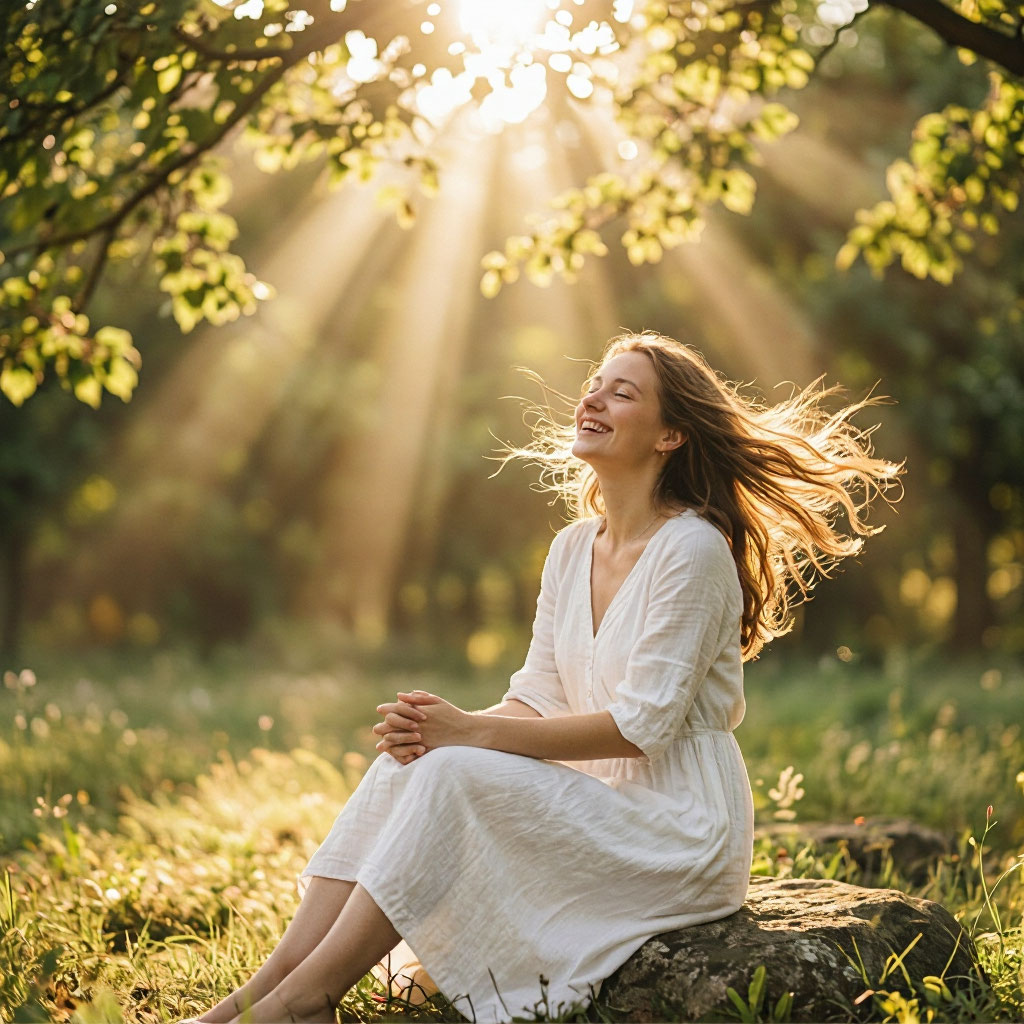

In [11]:
import base64
from PIL import Image

model_yart = f"art://{folder_id}/aliceai-image-art-3.0/latest"

def generate_image(prompt, size="1024x1024"):
    img = client.images.generate(
        model=model_yart,
        prompt=prompt,
        size=size
    )
    image_bytes = base64.b64decode(img.data[0].b64_json)
    return Image.open(io.BytesIO(image_bytes))

img = generate_image(concept)
img

А теперь - по улучшенному промпту от LLM:

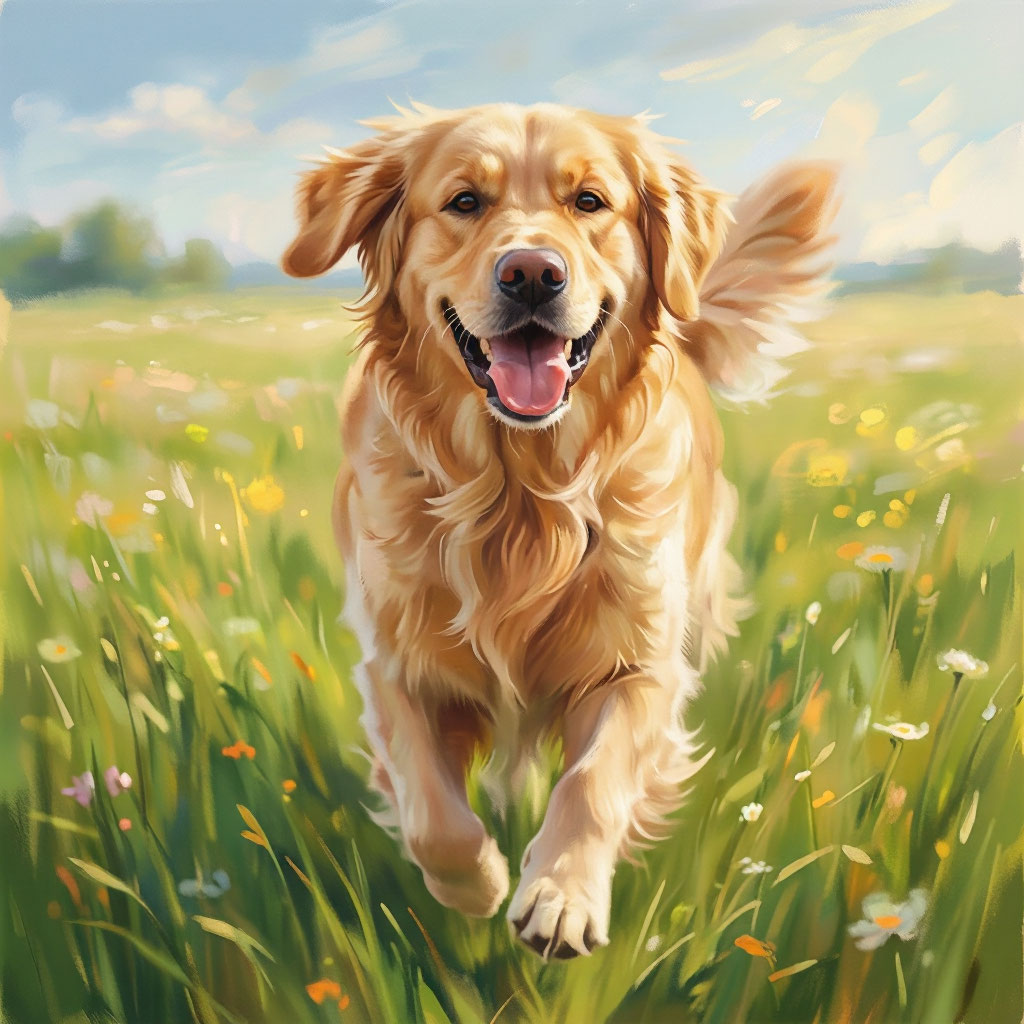

In [12]:
generate_image(res.output_text)

**Задание 1**: Используйте подход с улучшением промпта для того, чтобы автоматически сгенерировать картинки по нескольким исходным концепциям:

In [10]:
concepts = ["счастье","трансцендентность","познание","сферический конь в вакууме", "облако"]

# Напишите сюда ваш код
# Картинки можно показывать или сохранять на диск через `img.save("image.png")`

## VLM и структурный ответ

Мы можем также использовать мультимодальную модель для того, чтобы "посмотреть" на нарисованную картину и оценить, насколько она действительно отражает понятие счастья:

In [13]:
def image_to_base64(image):
    buffered = io.BytesIO()
    image.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode()

def get_content(prompt, image=None):
    if image:
        image_b64 = image_to_base64(image)
        return [
                    {
                        "type": "input_text",
                        "text": prompt
                    },
                    {
                        "type": "input_image",
                        "image_url": f"data:image/jpeg;base64,{image_b64}",
                        "detail" : "auto"
                    }
        ]
    else:
        return prompt

def gpt(prompt, model=model_deepseek, image=None):
    response = client.responses.create(
        model=model,
        input=[{"role": "user", "content": get_content(prompt, image)}]
    )
    return response.output_text

gpt(f"Посмотри на изображение и оцени, насколько оно отражает понятие {concept}. Приведи 5 советов, как улучшить изображение, чтобы оно отражало понятие {concept}",model_qwen,img)

'\n\nЭто изображение **отражает понятие счастья очень убедительно**, но скорее в его спокойном, умиротворяющем и чувственном аспекте.\n\n**Оценка:**\n*   **Выражение лица:** Улыбка женщины естественная, глаза закрыты или едва приоткрыты — это знак полного принятия момента и внутреннего удовлетворения.\n*   **Свет:** «Божественные лучи» (солнечные зайчики сквозь листву) символизируют надежду, тепло и просветление. Это мощный визуальный символ счастья.\n*   **Свобода:** Развевшиеся волосы и легкий ветер создают ощущение легкости и свободы от любых проблем.\n*   **Цветовая гамма:** Теплые золотистые тона и свежая зелень ассоциируются с жизненной энергией и природной гармонией.\n\nЭто изображение скорее о **благодарности и покое**, чем о бурном экстазе, что тоже является высшей формой счастья.\n\nВот **5 советов**, как можно улучшить изображение, чтобы сделать чувство счастья еще более ярким и всеобъемлющим:\n\n**1. Добавить элемент взаимодействия (Социальное счастье)**\nСчастье часто усил

Добавим **структурный ответ** к анализу изображения. Это нужно для того, чтобы получать ответ от визуальной модели в структурированном виде.

Нам нужно получить от модели:
- `fit` - число от 0 до 1, показывающее степень соответствия картинки понятию
- `recommendations` - список рекомендаций (можно в виде строки)

Опишем класс для представления ответа модели:


In [14]:
from pydantic import BaseModel

class VLMResponse(BaseModel):
    fit : float
    recommendations : str

Расширим функцию `gpt` для возможности задания формата ответа:

In [15]:
def gpt(prompt, model=model_deepseek, image=None, response_format=None):
    kwargs = {
        "model" : model,
        "input" : [{"role": "user", "content": get_content(prompt, image)}]
    }
    if response_format:
        kwargs['text_format'] = response_format
        response = client.responses.parse(**kwargs)
    else:
        response = client.responses.create(**kwargs)
    return response.output_parsed if response_format else response.output_text

Проверим:

In [16]:
res = gpt(f"""
   Проанализируй, насколько изображение иллюстрирует концепт '{concept}'.
   Верни ответ в виде JSON с полями:
    - fit : число от 0 до 1, характеризующее насколько изображение соответствует концепту
    - recommendations : текст с рекомендациями по улучшению изображения
   """, model=model_qwen,image=img, response_format=VLMResponse)
print(res)

fit=0.95 recommendations="Изображение превосходно передаёт концепт 'счастье' через улыбающееся лицо, расслабленную позу, естественное освещение и гармонию с природой. Для ещё большей эмоциональной глубины можно добавить лёгкий намёк на взаимодействие с окружением (например, прикосновение к траве или цветку) или слегка расширить композицию, чтобы включить больше элементов спокойствия (птица в небе, далёкий горизонт). Также стоит учесть, что слишком идеализированный свет может снижать ощущение аутентичности — небольшое смягчение бликов сделает образ более живым и человечным."



## Агентный цикл

Создадим автоматический генератор изображений, основанный на **агентном цикле**. Он будет итерационно улучшать генерируемое изображение на основе обратной связи от визуальной LLM.

Основная идея в том, что на вход мы будет подавать какую-то простую концепцию - *счастье* или *сложность*. На основе этой концепции:

* LLM генерирует промпт для рисования, продумывая, как лучше отобразить концепцию
* YandexART генерирует изображение
* Визуальная нейросеть VLM оценивает, насколько изображение соответствует концепции, и предлагает улучшения

После этого цикл повторяется.

```
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│ Концепция   │────▶│ LLM создаёт │────▶│ YandexART   │
│ (понятие)   │     │ промпт      │     │ рисует      │
└─────────────┘     └─────────────┘     └─────────────┘
                                              │
                                              ▼
┌─────────────┐     ┌─────────────┐     ┌─────────────┐
│ LLM улучшает│◀────│ Визуальная  │◀────│ Изображение │
│ промпт      │ Нет │ LLM (Gemma) │     │             │
└─────────────┘     └─────────────┘     └─────────────┘
       │                  │ Да
       │                  ▼
       └────────────▶ Готово!
```

**Задание 2**: Реализуйте такой агентный цикл улучшения изображения. В качестве подсказки ниже - возможные варианты промптов. В промптах используются плейсхолдеры, например, `{concept}` для названия концепта и `{feedback}` для обратной связи от VLM.

In [19]:
initial_prompt = """
Тебе нужно создать промпт для нейросети генерации изображений (YandexART).

Концепция для визуализации: "{concept}"

Создай промпт, который:
1. Визуально передаёт суть этого понятия через метафоры и символы
2. Описывает стиль, освещение и композицию
3. Создаёт запоминающийся художественный образ

Верни ТОЛЬКО сам промпт, без объяснений.
"""

refine_prompt = """
Тебе нужно создать промпт для нейросети генерации изображений (YandexART).

Концепция для визуализации: "{concept}"

Предыдущее изображение получило такую обратную связь: {feedback}

Создай НОВЫЙ, улучшенный промпт, учитывая эту обратную связь.
Промпт должен описывать визуальные элементы, стиль и композицию.
Верни ТОЛЬКО сам промпт, без объяснений.
"""

evaluation_prompt = """
   Проанализируй, насколько изображение иллюстрирует концепт '{concept}'.
   Верни ответ в виде JSON с полями:
    - fit : число от 0 до 1, характеризующее насколько изображение соответствует концепту
    - recommendations : текст с рекомендациями по улучшению изображения
"""

In [22]:
# Опишите агентский цикл, который будет циклически улучшать изображение
# для некоторого заданного понятия

# Ваш код тут!

Идея агентского цикла в генерации художественных произведений эксплуатировалась [Дмитрием Сошниковым](https://soshnikov.com/ru) в его работе [многоагентное рисование / VibeDraw](https://soshnikov.com/art/vibedraw/ru/)

### Выводы

В данной работе мы рассмотрели простейшие методы вызова LLM и генеративных моделей для изображений в Yandex Studio. 

### Об авторе 

Материалы были подготовлены [Дмитрием Сошниковым](https://soshnikov.com/ru). Дмитрий является основным разработчиком [Microsoft AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners), читает курс по Искусственному интеллекту в МАИ, является доцентом НИУ ВШЭ и техническим руководителем AI Lab Школы дизайна, консультантом Yadnex Cloud. Начал заниматься ИИ и многоагентными системами в 1995 году. Автор телеграм-канала [Облачный адвокат](http://t.me/shwarsico).
